# PyraFuse on mobile and edge devices: ExecuTorch

## Goal

Run the published PyraFuse **ExecuTorch** programs (`.pte`) exactly as an Android, iOS, React Native, Flutter, or embedded-Linux app would, and check them against the eager PyTorch model. The same `.pte` file that runs here is the one shipped inside an app.

| Target | Runs on | Precision |
| --- | --- | --- |
| `xnnpack_fp32` | CPU: Android, iOS, macOS, Linux/ARM edge boards | FP32 |
| `xnnpack_int8` | same CPUs, ~4x smaller file | INT8 weights, dynamic INT8 activations |
| `coreml_fp32` | iOS 17+ / macOS 14+ GPU and CPU via Core ML | FP32 |
| `vulkan_fp32` | Android GPU via Vulkan | FP32 |

Every program has the same contract:

- **input** `float32 [1, 3, 448, 448]`: RGB, resized (stretched) to 448 × 448 and **divided by 255**. ImageNet mean/std normalisation is inside the graph.
- **output** `float32 [1, 3, 448, 448]` logits for `0 = background`, `1 = fabric`, `2 = skin`; take `argmax` over dim 1.

On a Linux or Windows host the ExecuTorch Python runtime can execute the XNNPACK programs only. Core ML programs need Apple hardware and Vulkan programs need an Android GPU.

## Setup

ExecuTorch pins a specific PyTorch release (ExecuTorch 1.5 → torch 2.14), so use a dedicated environment:

```bash
python -m venv ~/.venvs/pyrafuse-mobile
source ~/.venvs/pyrafuse-mobile/bin/activate
pip install "torch==2.14.*" --index-url https://download.pytorch.org/whl/cpu
pip install "pyrafuse[mobile]" matplotlib ipykernel
```

From a development checkout, use `pip install -e ".[mobile]"` instead of the PyPI package.

In [1]:
from pathlib import Path
import json
import os
import statistics
import sys
import time

# Works when Jupyter is started from either the repo root or notebooks/.
start_dir = Path.cwd().resolve()
REPO = next(
    (candidate for candidate in (start_dir, start_dir.parent)
     if (candidate / 'pyrafuse').is_dir() and (candidate / 'models').is_dir()),
    None,
)
if REPO is None:
    raise RuntimeError('Start Jupyter from the repository root or notebooks/ directory.')
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

os.environ.setdefault('MPLCONFIGDIR', str(REPO / 'artifacts' / 'mplconfig'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

from importlib.metadata import version

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from PIL import Image
import torch
from executorch.runtime import Runtime

from transformers.utils import logging as hf_logging

from pyrafuse import download_mobile_model, load_pretrained
from pyrafuse.deploy.mobile_export import CLASS_NAMES, MobileSegmenter

hf_logging.disable_progress_bar()

print(f"executorch {version('executorch')} | torch {torch.__version__}")

executorch 1.5.1 | torch 2.14.0+cpu


## Parameters

`SOURCE = 'hub'` downloads the programs from [jamal-one/PyraFuse](https://huggingface.co/jamal-one/PyraFuse) (`mobile/<variant>/`); `'local'` uses programs written to `models/mobile/` by `scripts/export_mobile.py`. With `IMAGE_PATH = None` the first image in `data/raw/test` is used.

In [2]:
MODEL_SIZE = 'small'                          # 'small', 'small_plus', or 'base'
TARGETS = ('xnnpack_fp32', 'xnnpack_int8')    # programs runnable on this host
SOURCE = 'local'                              # 'local' or 'hub'
IMAGE_PATH = None                             # e.g. REPO / 'data/raw/test/example.jpg'
IMAGE_SIZE = 448
BENCHMARK_ITERATIONS = 10
OVERLAY_ALPHA = 0.48

def program_path(target):
    local = REPO / 'models' / 'mobile' / MODEL_SIZE / f'pyrafuse_{MODEL_SIZE}_{target}.pte'
    if SOURCE == 'local' and local.is_file():
        return local
    return download_mobile_model(MODEL_SIZE, target)

PROGRAMS = {target: program_path(target) for target in TARGETS}
for target, path in PROGRAMS.items():
    print(f'{target:>13}: {path.stat().st_size / 2**20:6.1f} MiB  {path.name}')

 xnnpack_fp32:   86.6 MiB  pyrafuse_small_xnnpack_fp32.pte
 xnnpack_int8:   22.3 MiB  pyrafuse_small_xnnpack_int8.pte


## 1. Inspect a program

A `.pte` file carries its method signature. This is what `react-native-executorch` validates when it loads a semantic-segmentation model: one `float32 [1, 3, H, W]` input and one `float32 [1, K, H, W]` output.

In [3]:
runtime = Runtime.get()
methods = {target: runtime.load_program(path).load_method('forward')
           for target, path in PROGRAMS.items()}
meta = methods[TARGETS[0]].metadata
print(meta)

MethodMeta(name='forward', num_inputs=1, input_tensor_meta=['TensorInfo(sizes=[1, 3, 448, 448], dtype=Float, is_memory_planned=True, nbytes=2408448)'], num_outputs=1, output_tensor_meta=['TensorInfo(sizes=[1, 3, 448, 448], dtype=Float, is_memory_planned=True, nbytes=2408448)'])


## 2. Prepare the input as an app would

Stretch-resize to 448 × 448, keep RGB order, scale to `[0, 1]`, and lay out as NCHW. There is no mean/std step: it is part of the program.

In [4]:
CLASS_COLORS = np.array(((24, 24, 32), (242, 147, 62), (44, 177, 154)), dtype=np.uint8)

def choose_image(path):
    if path is not None:
        return Path(path)
    candidates = sorted((REPO / 'data' / 'raw' / 'test').glob('*.jpg'))
    if not candidates:
        raise FileNotFoundError('No .jpg files in data/raw/test; set IMAGE_PATH explicitly.')
    return candidates[0]

def to_input(rgb, size):
    resized = Image.fromarray(rgb).resize((size, size), Image.BILINEAR)
    array = np.asarray(resized, dtype=np.float32) / 255.0
    return torch.from_numpy(array).permute(2, 0, 1).unsqueeze(0).contiguous()

def to_mask(logits, height, width):
    # Argmax at model resolution, then nearest-neighbour resize to the photo,
    # which is what a mobile app does with the returned class map.
    classes = logits.argmax(1)[0].to(torch.uint8).numpy()
    return np.asarray(Image.fromarray(classes).resize((width, height), Image.NEAREST))

def overlay(rgb, mask):
    return (rgb * (1 - OVERLAY_ALPHA) + CLASS_COLORS[mask] * OVERLAY_ALPHA).astype(np.uint8)

image_path = choose_image(IMAGE_PATH)
source_rgb = np.asarray(Image.open(image_path).convert('RGB'))
image = to_input(source_rgb, IMAGE_SIZE)
print(image_path.name, source_rgb.shape, '->', tuple(image.shape), image.dtype,
      f'range [{image.min():.2f}, {image.max():.2f}]')

003d41dd20f271d27219fe7ee6de727d.jpg (1024, 852, 3) -> (1, 3, 448, 448) torch.float32 range [0.00, 1.00]


## 3. Run the ExecuTorch programs and the PyTorch reference

The reference wraps the same checkpoint in `MobileSegmenter`, the exact module that was exported, so both paths receive the identical `[0, 1]` tensor.

In [5]:
reference = MobileSegmenter(load_pretrained(MODEL_SIZE)).eval()
with torch.inference_mode():
    reference_logits = reference(image)
height, width = source_rgb.shape[:2]
masks = {'pytorch': to_mask(reference_logits, height, width)}
logits = {}
for target, method in methods.items():
    logits[target] = method.execute([image])[0]
    assert logits[target].shape == reference_logits.shape
    assert torch.isfinite(logits[target]).all(), f'{target} produced non-finite logits'
    masks[target] = to_mask(logits[target], height, width)
    agreement = (logits[target].argmax(1) == reference_logits.argmax(1)).float().mean()
    print(f'{target:>13}: max |logit diff| {(logits[target] - reference_logits).abs().max():.4f}'
          f' | pixel agreement with PyTorch {agreement:.2%}')

 xnnpack_fp32: max |logit diff| 0.0361 | pixel agreement with PyTorch 100.00%
 xnnpack_int8: max |logit diff| 19.7005 | pixel agreement with PyTorch 99.80%


## 4. Visualise

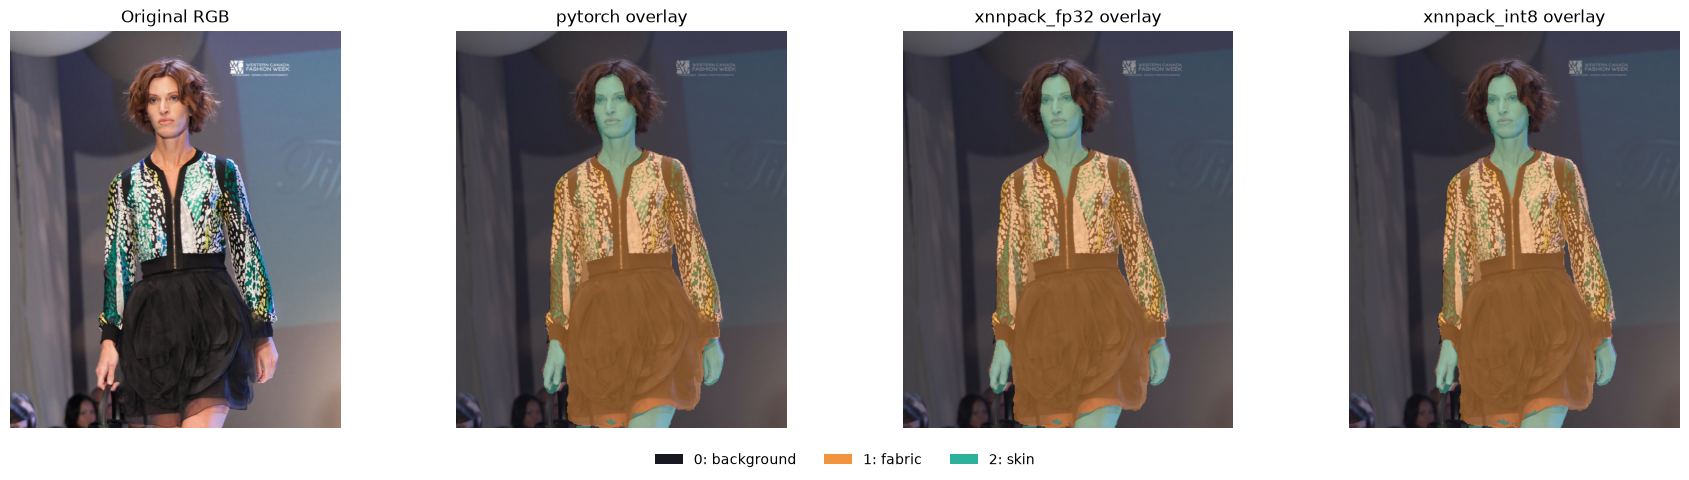

In [6]:
panels = [source_rgb] + [overlay(source_rgb, masks[name]) for name in masks]
titles = ['Original RGB'] + [f'{name} overlay' for name in masks]
figure, axes = plt.subplots(1, len(panels), figsize=(4.5 * len(panels), 4.8))
for axis, panel, title in zip(axes, panels, titles):
    axis.imshow(panel)
    axis.set_title(title)
    axis.axis('off')
legend = [Patch(facecolor=CLASS_COLORS[i] / 255.0, label=f'{i}: {name}')
          for i, name in enumerate(CLASS_NAMES)]
figure.legend(handles=legend, loc='lower center', ncol=3, frameon=False)
figure.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()

## 5. Host-CPU latency

Median of repeated `forward` calls after one warm-up. These are desktop-CPU numbers and only indicate relative cost; measure phones with the ExecuTorch benchmark apps or in your own app.

In [7]:
def median_ms(fn, iterations=BENCHMARK_ITERATIONS):
    fn()
    times = []
    for _ in range(iterations):
        start = time.perf_counter()
        fn()
        times.append((time.perf_counter() - start) * 1e3)
    return statistics.median(times)

with torch.inference_mode():
    print(f"{'pytorch':>13}: {median_ms(lambda: reference(image)):7.1f} ms")
for target, method in methods.items():
    print(f'{target:>13}: {median_ms(lambda: method.execute([image])):7.1f} ms')

      pytorch:   288.5 ms


 xnnpack_fp32:   456.2 ms


 xnnpack_int8:   440.8 ms


## 6. Held-out accuracy of the published programs

`models/mobile/manifest.json` records every exported program with its SHA-256, size, delegation summary, and, for programs that can run on a Linux host, mIoU on the first 200 images of the held-out test split (`scripts/export_mobile.py --eval`).

In [8]:
manifest_path = REPO / 'models' / 'mobile' / 'manifest.json'
manifest = json.loads(manifest_path.read_text())
print(manifest['eval_protocol'])
print(f"{'program':<50}{'MiB':>7}{'mIoU':>8}{'bg':>7}{'fabric':>8}{'skin':>7}{'agree':>9}")
for variant, ref in manifest['pytorch_reference'].items():
    iou = ref['iou']
    print(f"{variant + ' (PyTorch reference)':<50}{'':>7}{ref['miou']:>8.4f}"
          f"{iou['background']:>7.3f}{iou['fabric']:>8.3f}{iou['skin']:>7.3f}")
    for record in manifest['programs']:
        if record['variant'] != variant:
            continue
        size = record['size_bytes'] / 2**20
        result = record.get('eval')
        if result is None:
            print(f"{record['file']:<50}{size:>7.1f}{'needs device':>39}")
            continue
        iou = result['iou']
        print(f"{record['file']:<50}{size:>7.1f}{result['miou']:>8.4f}{iou['background']:>7.3f}"
              f"{iou['fabric']:>8.3f}{iou['skin']:>7.3f}{result['pixel_agreement_vs_pytorch']:>9.2%}")

first 200 images of the held-out test split (seed 42), 448 px stretch-resize; host CPU x86_64
program                                               MiB    mIoU     bg  fabric   skin    agree
small (PyTorch reference)                                  0.9070  0.982   0.934  0.805
small/pyrafuse_small_xnnpack_fp32.pte                86.6  0.9070  0.982   0.934  0.805  100.00%
small/pyrafuse_small_xnnpack_int8.pte                22.3  0.9064  0.982   0.933  0.804   99.78%
small/pyrafuse_small_coreml_fp32.pte                 88.0                           needs device
small/pyrafuse_small_vulkan_fp32.pte                 86.6                           needs device
small_plus (PyTorch reference)                             0.9079  0.981   0.935  0.807
small_plus/pyrafuse_small_plus_xnnpack_fp32.pte     113.7  0.9079  0.981   0.935  0.807  100.00%
small_plus/pyrafuse_small_plus_xnnpack_int8.pte      29.2  0.9069  0.981   0.934  0.806   99.74%
small_plus/pyrafuse_small_plus_coreml_fp32.pte     

## 7. Re-export (optional)

The published programs are produced by `scripts/export_mobile.py`, a thin wrapper around `pyrafuse.deploy.mobile_export.export_mobile`. Export a fine-tuned checkpoint, or another input size (any multiple of 16; smaller is faster, validate mIoU first), like this:

In [9]:
RUN_EXPORT = False

if RUN_EXPORT:
    from pyrafuse.deploy.mobile_export import export_mobile
    from pyrafuse.zoo import resolve_checkpoint

    records = export_mobile(
        resolve_checkpoint(MODEL_SIZE),
        REPO / 'artifacts' / 'mobile_export' / MODEL_SIZE,
        label=MODEL_SIZE,
        targets=['xnnpack_fp32', 'xnnpack_int8', 'coreml_fp32', 'vulkan_fp32'],
        image_size=IMAGE_SIZE,
    )
    for record in records:
        print(record['file'], f"{record['size_bytes'] / 2**20:.1f} MiB")

## Next steps

- **React Native**: load the `.pte` with `useSemanticSegmenter` from `react-native-executorch` (labels `background`, `fabric`, `skin`; `normalizeOpts: { alpha: 1 / 255, beta: 0 }`).
- **Flutter**: `executorch_flutter`; **Android**: `org.pytorch:executorch-android`; **iOS**: the ExecuTorch Swift package; **embedded Linux**: the ExecuTorch C++ `Module` API.
- Pick `xnnpack_int8` for the smallest download, `coreml_fp32` on iOS for GPU execution, and `vulkan_fp32` on Android GPUs after testing it on your target devices.
- See the README section *Mobile and edge deployment* for copy-paste snippets for each platform.